## Assignment: Object detection
- Alumno 1: Vittorio Alberto Gianfrate
- Alumno 2: Alex Ferroni
- Alumno 3:

The goals of the assignment are:
* Put into practice acquired knowledge to detect and recognize objects of interest within a satellite image.

To address this problem, you must choose one of the following options:
*	Implement a sliding window strategy to process the whole image, and then train a classifier that determines whether each window includes or not an object of interest. In this way, you can use previous image classification model to infer the object category.
*	Build a single-stage object detection model (e.g., YOLO, SSD, RetinaNet, etc.).
*	Build a two-stage object detection model (e.g., Faster R-CNN, R-FCN, etc.).

Follow the link below to download the detection data set “xview_detection”: [https://drive.upm.es/s/P7nEf3Bygns7tbM](https://drive.upm.es/s/P7nEf3Bygns7tbM)

In [22]:
!pip install rasterio --quiet
!pip install torch torchvision --quiet
!python -m pip install 'git+https://github.com/facebookresearch/detectron2.git' --quiet

import torch
print("CUDA disponibile:", torch.cuda.is_available())



  Preparing metadata (setup.py) ... done
CUDA disponibile: True


In [23]:

print("CUDA disponibile:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA disponibile: True
GPU: Tesla P100-PCIE-16GB


In [24]:
import uuid
import numpy as np

class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])  # (pt_x, pt_y, pt_x+width, pt_y+height)
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)

In [25]:
categories = {0: 'Small car', 1: 'Bus', 2: 'Truck', 3: 'Building'}

In [26]:
import warnings
import rasterio
import numpy as np

def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
    base_path = '/kaggle/input/datasets/alexferroni/detection/'
    
    src_raster = rasterio.open(base_path + filename, 'r')
    # RasterIO to OpenCV (see inconsistencies between libjpeg and libjpeg-turbo)
    input_type = src_raster.profile['dtype']
    input_channels = src_raster.count
    img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=input_type)
    for band in range(input_channels):
        img[:, :, band] = src_raster.read(band+1)
    return img

#### Training
Design and train a detector to deal with the “xview_detection” perception task.

In [27]:
import json

# Load database
json_file = '/kaggle/input/datasets/alexferroni/detection/xview_det_train.json'
with open(json_file) as ifs:
    json_data = json.load(ifs)
ifs.close()
print("Annotazioni caricate con successo!")

Annotazioni caricate con successo!


In [28]:
import numpy as np

counts = dict.fromkeys(categories.values(), 0)
anns = []
for json_img in json_data['images'].values():
    image = GenericImage(json_img['filename'])
    image.tile = np.array([0, 0, json_img['width'], json_img['height']])
    for json_ann in [elem for elem in json_data['annotations'].values() if elem['image_id'] == json_img['image_id']]:
        obj = GenericObject()
        obj.id = json_ann['image_id']
        obj.bb = (int(json_ann['bbox'][0]), int(json_ann['bbox'][1]), int(json_ann['bbox'][2]), int(json_ann['bbox'][3]))
        obj.category = json_ann['category_id']
        counts[obj.category] += 1
        image.add_object(obj)
    anns.append(image)
print(counts)

{'Small car': 188300, 'Bus': 6269, 'Truck': 10600, 'Building': 275943}


In [29]:
from sklearn.model_selection import train_test_split

anns_train, anns_valid = train_test_split(anns, test_size=0.1, random_state=1, shuffle=True)
print('Number of training images: ' + str(len(anns_train)))
print('Number of validation images: ' + str(len(anns_valid)))

Number of training images: 6845
Number of validation images: 761


In [30]:
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.structures import BoxMode

# 1. Creiamo un dizionario inverso: da 'Small car' -> 0, 'Bus' -> 1, ecc.
category_name_to_id = {name: id for id, name in categories.items()}

def get_xview_dicts(anns_list):
    dataset_dicts = []
    for idx, img_ann in enumerate(anns_list):
        img = load_geoimage(img_ann.filename)
        h, w = img.shape[:2]
        objs = []
        for obj in img_ann.objects:
            x1, y1, x2, y2 = obj.bb
            
            # 2. Invece di usare int(obj.category), usiamo il dizionario per trovare l'ID numerico
            cat_id = category_name_to_id[obj.category]
            
            objs.append({
                "bbox": [x1, y1, x2, y2],
                "bbox_mode": BoxMode.XYXY_ABS,
                "category_id": cat_id, # <-- FIX QUI!
            })
        dataset_dicts.append({
            "file_name": '/kaggle/input/datasets/alexferroni/detection/' + img_ann.filename,
            "image_id": idx,
            "height": h,
            "width": w,
            "annotations": objs,
        })
    return dataset_dicts

# Rimuovi registrazioni precedenti se esiste già
for d in ["xview_train", "xview_valid"]:
    if d in DatasetCatalog.list():
        DatasetCatalog.remove(d)

DatasetCatalog.register("xview_train", lambda: get_xview_dicts(anns_train))
DatasetCatalog.register("xview_valid", lambda: get_xview_dicts(anns_valid))
MetadataCatalog.get("xview_train").set(thing_classes=list(categories.values()))
MetadataCatalog.get("xview_valid").set(thing_classes=list(categories.values()))
print("Dataset registrato con successo!")


Dataset registrato con successo!


In [31]:
from detectron2 import model_zoo
from detectron2.config import get_cfg
import os

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
))
cfg.DATASETS.TRAIN = ("xview_train",)
cfg.DATASETS.TEST  = ("xview_valid",)
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
)
cfg.SOLVER.IMS_PER_BATCH  = 2
cfg.SOLVER.BASE_LR        = 0.001
cfg.SOLVER.MAX_ITER       = 40000
cfg.SOLVER.STEPS          = (25000, 30000)
cfg.SOLVER.CHECKPOINT_PERIOD = 2000
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = len(categories)
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.2
cfg.INPUT.MIN_SIZE_TRAIN = (640,)
cfg.INPUT.MAX_SIZE_TRAIN = 640
cfg.INPUT.MIN_SIZE_TEST  = 640
cfg.INPUT.MAX_SIZE_TEST  = 640
cfg.OUTPUT_DIR = "/kaggle/working/faster_rcnn_output"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
print("Config pronta!")



Config pronta!


In [32]:
from detectron2.engine import DefaultTrainer

trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
print("Inizio training Faster R-CNN...")
trainer.train()
print("Training completato!")


[03/21 16:01:40 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (5, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (5,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (16, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (16,) in the model! You might want to double check if this is expected.
Some model parameters or buffers are not found in the checkpoint:
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, 

Inizio training Faster R-CNN...
[03/21 16:02:23 d2.engine.train_loop]: Starting training from iteration 0
[03/21 16:02:26 d2.utils.events]:  eta: 1:35:59  iter: 19  total_loss: 3.902  loss_cls: 1.59  loss_box_reg: 0.6321  loss_rpn_cls: 1.295  loss_rpn_loc: 0.3741    time: 0.1447  last_time: 0.1406  data_time: 0.0146  last_data_time: 0.0045   lr: 1.9981e-05  max_mem: 3638M
[03/21 16:02:29 d2.utils.events]:  eta: 1:35:53  iter: 39  total_loss: 2.747  loss_cls: 1.343  loss_box_reg: 0.5649  loss_rpn_cls: 0.5056  loss_rpn_loc: 0.3479    time: 0.1447  last_time: 0.1473  data_time: 0.0056  last_data_time: 0.0055   lr: 3.9961e-05  max_mem: 3638M
[03/21 16:02:32 d2.utils.events]:  eta: 1:36:21  iter: 59  total_loss: 2.343  loss_cls: 1.005  loss_box_reg: 0.5363  loss_rpn_cls: 0.3917  loss_rpn_loc: 0.3464    time: 0.1461  last_time: 0.1440  data_time: 0.0056  last_data_time: 0.0057   lr: 5.9941e-05  max_mem: 3638M
[03/21 16:02:35 d2.utils.events]:  eta: 1:36:25  iter: 79  total_loss: 2.092  loss_

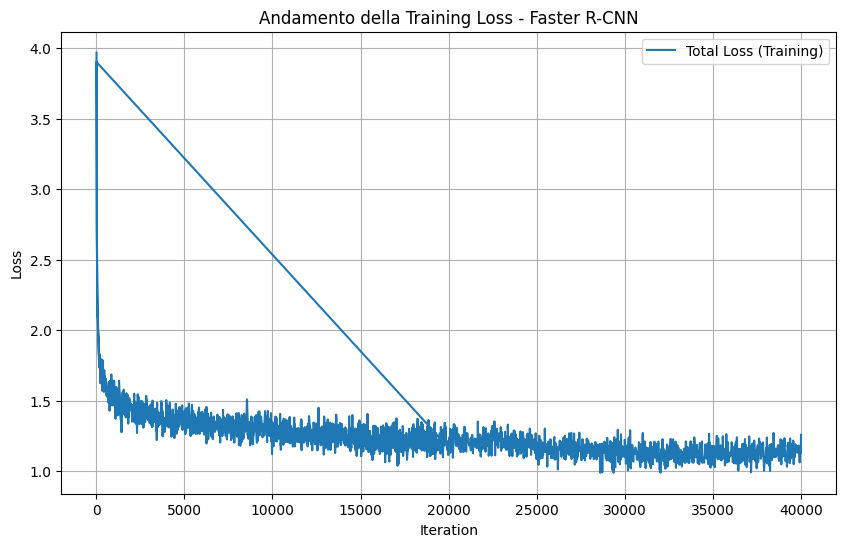

In [33]:
import json
import matplotlib.pyplot as plt

# Percorso del file delle metriche generato da Detectron2
metrics_file = os.path.join(cfg.OUTPUT_DIR, "metrics.json")

train_losses = []
iters = []

with open(metrics_file, 'r') as f:
    for line in f:
        m = json.loads(line)
        if 'total_loss' in m:
            train_losses.append(m['total_loss'])
            iters.append(m['iteration'])

plt.figure(figsize=(10, 6))
plt.plot(iters, train_losses, label='Total Loss (Training)')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Andamento della Training Loss - Faster R-CNN')
plt.legend()
plt.grid(True)
plt.show()

#### Validation
Compute validation metrics.

In [34]:
import matplotlib.pyplot as plt
import matplotlib.colors as col
import numpy as np
%matplotlib inline

def area_intersection(boxes, box):
    xmin = np.maximum(np.min(boxes[:, 0::2], axis=1), np.min(box[0::2]))
    ymin = np.maximum(np.min(boxes[:, 1::2], axis=1), np.min(box[1::2]))
    xmax = np.minimum(np.max(boxes[:, 0::2], axis=1), np.max(box[0::2]))
    ymax = np.minimum(np.max(boxes[:, 1::2], axis=1), np.max(box[1::2]))
    w = np.maximum(xmax - xmin + 1.0, 0.0)
    h = np.maximum(ymax - ymin + 1.0, 0.0)
    return w * h

def area_union(boxes, box):
    area_anns = (np.max(box[0::2])-np.min(box[0::2])+1.0) * (np.max(box[1::2])-np.min(box[1::2])+1.0)
    area_pred = (np.max(boxes[:, 0::2], axis=1)-np.min(boxes[:, 0::2], axis=1)+1.0) * (np.max(boxes[:, 1::2], axis=1)-np.min(boxes[:, 1::2], axis=1)+1.0)
    return area_anns + area_pred - area_intersection(boxes, box)

def calc_iou(boxes, box):
    iou = area_intersection(boxes, box) / area_union(boxes, box)
    max_value = np.max(iou)
    max_index = np.argmax(iou)
    return max_value, max_index

def calc_ap(rec, prec):
    # First append sentinel values at the end
    mrec = np.concatenate(([0.0], rec, [1.0]))
    mpre = np.concatenate(([0.0], prec, [0.0]))
    # Compute the precision envelope
    for i in range(mpre.size-1, 0, -1):
        mpre[i-1] = np.maximum(mpre[i-1], mpre[i])
    # To calculate area under PR curve, look for points where X axis (recall) changes value
    i = np.where(mrec[1:] != mrec[:-1])[0]
    # and sum (\Delta recall) * prec
    ap = np.sum((mrec[i+1] - mrec[i]) * mpre[i+1])
    return ap

def draw_confusion_matrix(cm, categories):
    # Draw confusion matrix
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.get_cmap('Blues'))
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=categories, yticklabels=categories, ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show()

def draw_precision_recall(precisions, recalls, categories):
    # Draw precision-recall curves for each category
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    plt.axis([0, 1, 0, 1])
    c_dark = list(filter(lambda x: x.startswith('dark'), col.cnames.keys()))
    aps = []
    # Compare categories for a specific algorithm
    for idx in range(len(categories)):
        plt.plot(recalls[idx], precisions[idx], color=c_dark[idx], label=categories[idx], linewidth=4.0)
        aps.append(calc_ap(recalls[idx], precisions[idx]))
    handles, labels = ax.get_legend_handles_labels()
    labels = [str(val + ' [' + "{:.3f}".format(aps[idx]) + ']') for idx, val in enumerate(labels)]
    handles = [h for (ap, h) in sorted(zip(aps, handles), key=lambda x: x[0], reverse=True)]
    labels = [l for (ap, l) in sorted(zip(aps, labels), key=lambda x: x[0], reverse=True)]
    leg = plt.legend(handles, labels, loc='upper right')
    leg.set_zorder(100)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.grid("on", linestyle="--", linewidth=2.0)
    fig.tight_layout()
    plt.show()

In [35]:
from detectron2.engine import DefaultPredictor
from tqdm import tqdm

# Carica il modello migliore
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.2
predictor = DefaultPredictor(cfg)

annotations, predictions = {}, {}
for ann in tqdm(anns_valid):
    annotations.setdefault(ann.filename, {})
    predictions.setdefault(ann.filename, {})

    # Salva annotazioni GT (identico al tuo)
    for obj in ann.objects:
        annotations[ann.filename].setdefault(obj.category, {'bbox': []})
        annotations[ann.filename][obj.category]['bbox'].append(obj.bb)

    # Inference Detectron2
    img = load_geoimage(ann.filename)
    img_bgr = img[:, :, :3].copy()
    img_bgr = img_bgr[:, :, ::-1]  # RGB → BGR per Detectron2
    outputs = predictor(img_bgr)
    instances = outputs["instances"].to("cpu")

    for i in range(len(instances)):
        obj = GenericObject()
        box = instances.pred_boxes[i].tensor.numpy()[0]
        obj.bb = (float(box[0]), float(box[1]), float(box[2]), float(box[3]))
        # category: indice intero → nome stringa
        cat_idx = int(instances.pred_classes[i])
        obj.category = cat_idx  # ← manteniamo int come nel tuo notebook
        obj.score = float(instances.scores[i])
        cat_name = categories[cat_idx]
        predictions[ann.filename].setdefault(cat_name, {'bbox': [], 'confidence': []})
        predictions[ann.filename][cat_name]['bbox'].append(obj.bb)
        predictions[ann.filename][cat_name]['confidence'].append(obj.score)


[03/21 17:39:38 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/faster_rcnn_output/model_final.pth ...


100%|██████████| 761/761 [00:42<00:00, 17.73it/s]


In [36]:
# Cella 14 — calcolo TP/FP/FN
threshold = 0.5
default_cls = 'BACKGROUND'
y_true, y_pred_list = [], []
tps, confidences = dict(), dict()

for cls in categories.values():
    tps[cls], confidences[cls] = [], []
    for f in predictions:
        pred_boxes, pred_confidences = [], []
        if cls in predictions[f].keys():
            for idx in range(len(predictions[f][cls]['bbox'])):
                pred_boxes.append(predictions[f][cls]['bbox'][idx])
                pred_confidences.append(predictions[f][cls]['confidence'][idx])
            sorted_ind = np.argsort(-np.array(pred_confidences))
            pred_boxes = np.array(pred_boxes)[sorted_ind, :]
            pred_boxes = np.array(pred_boxes).astype(float)
        anno_boxes = []
        if cls in annotations[f].keys():
            anno_boxes = annotations[f][cls]['bbox']
        anno_boxes = np.array(anno_boxes).astype(float)
        anno_indices = list(range(len(anno_boxes)))
        for pred_idx, pred_box in enumerate(pred_boxes):
            iou_value, ann_index = calc_iou(anno_boxes, pred_box) if len(anno_boxes) > 0 else (-1, -1)
            if iou_value > threshold and ann_index in anno_indices:
                anno_indices.remove(int(ann_index))
                tps[cls] += [1.0]
                y_true += [cls]
            else:
                tps[cls] += [0.0]
                y_true += [default_cls]
            y_pred_list += [cls]
            confidences[cls] += [pred_confidences[pred_idx] if pred_confidences else 0.0]
        y_true += [cls] * len(anno_indices)
        y_pred_list += [default_cls] * len(anno_indices)

y_true = np.array(y_true)
y_pred_arr = np.array(y_pred_list)


> Small car: Recall: 54.745% Precision: 62.511% AP: 45.946%
> Bus: Recall: 25.781% Precision: 30.165% AP: 13.781%
> Truck: Recall: 22.797% Precision: 21.480% AP: 9.393%
> Building: Recall: 54.052% Precision: 57.117% AP: 44.179%
mAccuracy:  38.324%
mRecall:    31.475%
mPrecision: 34.254%
mAP:        28.325%
Confusion matrix:
[[    0  5746   382   870 11654]
 [ 7920  9581     0     0     0]
 [  475     0   165     0     0]
 [  806     0     0   238     0]
 [13195     0     0     0 15522]]


/tmp/ipykernel_55/2574756117.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.get_cmap('Blues'))


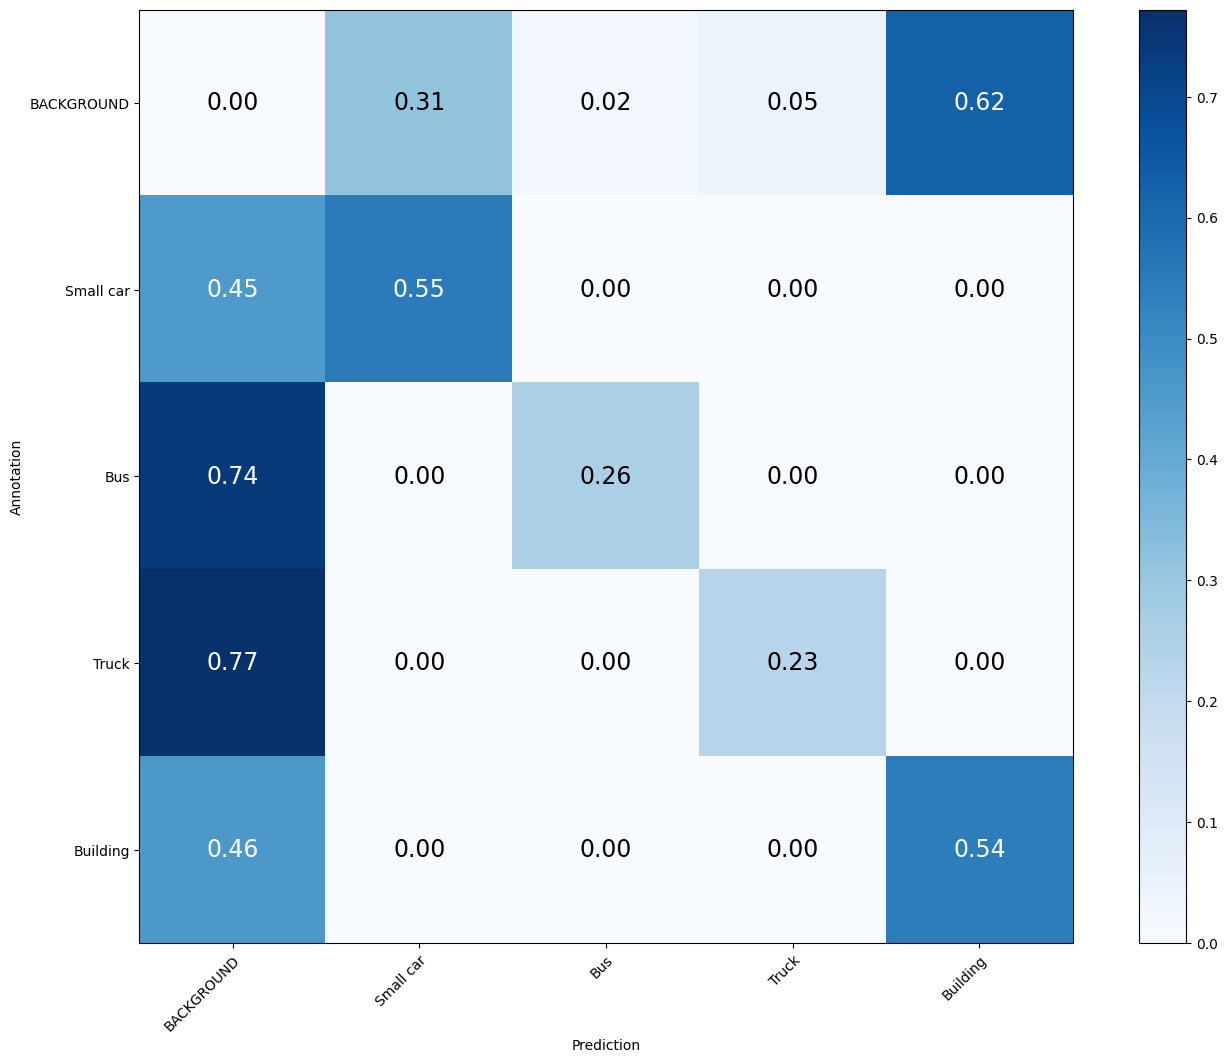

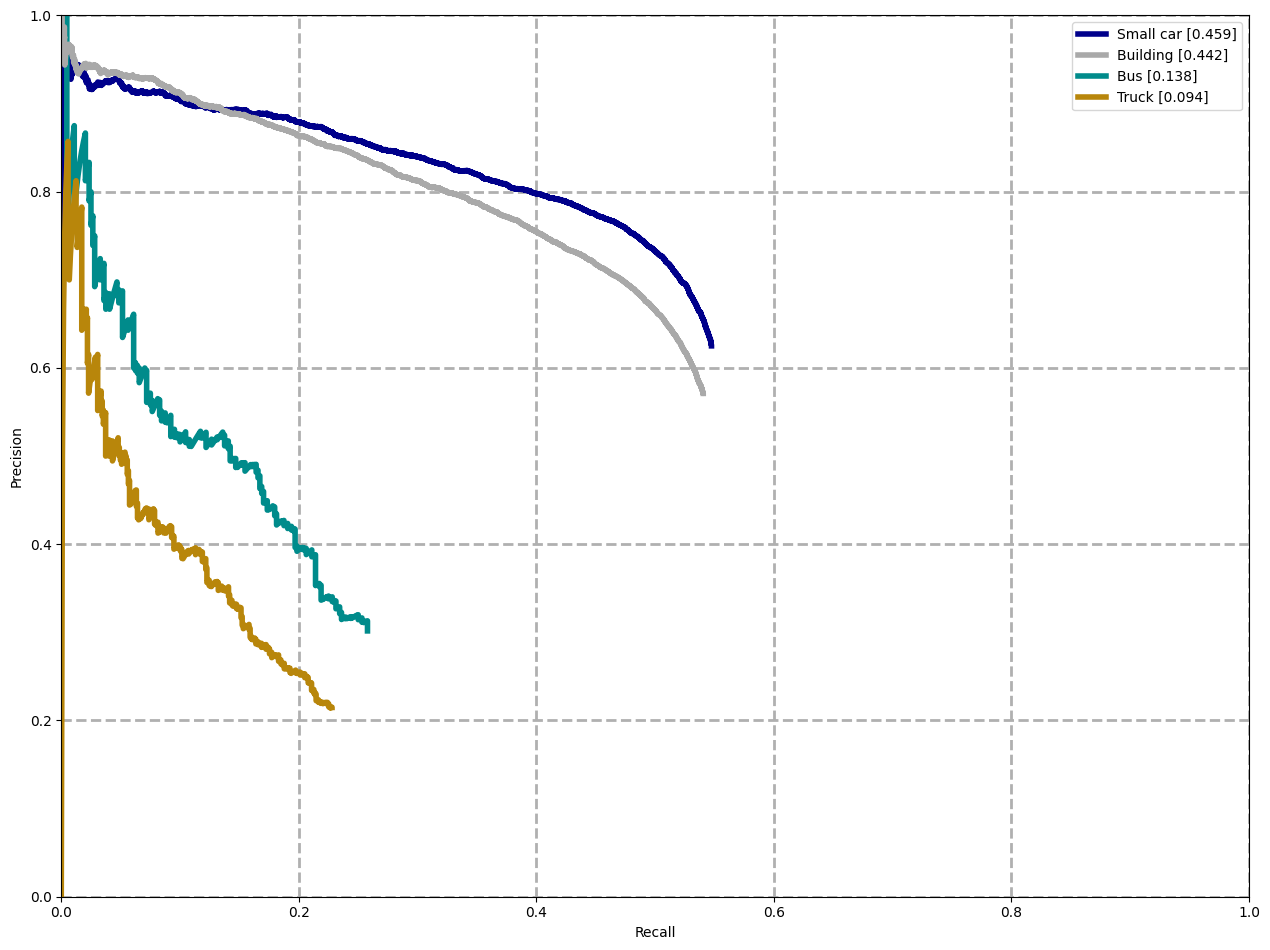

In [37]:
# Cella 15 — AP, mAP, confusion matrix, precision-recall
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score

precision_list, recall_list, ap_list = [], [], []
for cls in categories.values():
    sorted_ind = np.argsort(-np.array(confidences[cls]))
    tp = np.cumsum(np.array(tps[cls])[sorted_ind], dtype=float)
    recall    = np.array([0.0]) if len(tp) == 0 else tp / np.maximum(np.sum(y_true == cls), np.finfo(np.float64).eps)
    precision = np.array([0.0]) if len(tp) == 0 else tp / np.maximum(list(range(1, np.sum(y_pred_arr == cls)+1)), np.finfo(np.float64).eps)
    ap = calc_ap(recall, precision)
    print('> %s: Recall: %.3f%% Precision: %.3f%% AP: %.3f%%' % (cls, recall[-1]*100, precision[-1]*100, ap*100))
    precision_list.append(precision)
    recall_list.append(recall)
    ap_list.append(ap)

mean_ap = np.mean(ap_list)
print('mAccuracy:  %.3f%%' % (accuracy_score(y_true, y_pred_arr)*100))
print('mRecall:    %.3f%%' % (recall_score(y_true, y_pred_arr, average='macro', zero_division=1)*100))
print('mPrecision: %.3f%%' % (precision_score(y_true, y_pred_arr, average='macro', zero_division=1)*100))
print('mAP:        %.3f%%' % (mean_ap*100))

names = list(categories.values()).copy()
names.insert(0, default_cls)
cm = confusion_matrix(y_true, y_pred_arr, labels=names)
print('Confusion matrix:')
print(cm)
draw_confusion_matrix(cm, names)
draw_precision_recall(precision_list, recall_list, list(categories.values()))


#### Testing
Try to improve the results provided in the competition.

In [38]:
import os
import numpy as np

# CAMBIATO: Rinominato da 'anns' a 'anns_test' per evitare conflitti
anns_test = [] 
test_dir = '/kaggle/input/datasets/alexferroni/detection/xview_test'

for (dirpath, dirnames, filenames) in os.walk(test_dir):
    for filename in filenames:
        # Inseriamo esplicitamente solo la cartella e il nome del file
        image = GenericImage('xview_test/' + filename)
        image.tile = np.array([0, 0, 640, 640])
        anns_test.append(image)
        
print('Number of testing images: ' + str(len(anns_test)))

Number of testing images: 852


In [39]:
from tqdm import tqdm

# Inference con Detectron2
predictions = {}
for ann in tqdm(anns_test):
    img = load_geoimage(ann.filename)
    img_bgr = img[:, :, :3].copy()[:, :, ::-1]  # RGB → BGR per Detectron2
    outputs = predictor(img_bgr)
    instances = outputs["instances"].to("cpu")

    predictions.setdefault(ann.filename, {})
    for i in range(len(instances)):
        box   = instances.pred_boxes[i].tensor.numpy()[0]
        cat_idx = int(instances.pred_classes[i])
        score = float(instances.scores[i])
        obj = GenericObject()
        obj.bb = (float(box[0]), float(box[1]), float(box[2]), float(box[3]))
        obj.category = categories[cat_idx]
        obj.score = score
        predictions[ann.filename].setdefault(obj.category, {'bbox': [], 'confidence': []})
        predictions[ann.filename][obj.category]['bbox'].append(obj.bb)
        predictions[ann.filename][obj.category]['confidence'].append(obj.score)

# Genera JSON nel formato IDENTICO al tuo notebook
predictions_data = {"images": {}, "annotations": {}, "categories": {}}
predictions_data["categories"] = categories

imgs_idx, annos_idx = 0, 0
for pred in predictions:
    num_objects = 0
    for cat in predictions[pred]:
        num_objects += len(predictions[pred][cat]['bbox'])  # ✅ fix bug del tuo originale

    image_data = {
        "image_id": pred.split('/')[-1],
        "filename": pred,
        "num_objects": num_objects,
        "width": 640,
        "height": 640
    }
    predictions_data["images"][imgs_idx] = image_data
    imgs_idx += 1

    for cat in predictions[pred]:
        for i in range(len(predictions[pred][cat]['bbox'])):
            bbox = predictions[pred][cat]['bbox'][i]
            conf = predictions[pred][cat]['confidence'][i]
            annotation_data = {
                "image_id": pred.split('/')[-1],
                "category_id": cat,
                "bbox": (int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3])),
                "confidence": str(conf)
            }
            predictions_data["annotations"][annos_idx] = annotation_data
            annos_idx += 1

100%|██████████| 852/852 [00:48<00:00, 17.65it/s]


In [40]:
with open("prediction.json", "w") as outfile:
    json.dump(predictions_data, outfile)